In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial # reduces arguments to function by making some subset implicit

from jax.example_libraries import stax

# visualization
import matplotlib.pyplot as plt
from functools import partial

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

/tmp/ipykernel_942355/1538786404.py:14: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


gpu


In [2]:
def normalize_dp(state):
  # wrap generalized coordinates to [-pi, pi]
  return jnp.concatenate([
    (state[0] * 0)[None],
    (state[1])[None],
    (state[2] * 0)[None],
    state[3:]],
    )

def rk4_step(f, x, t, h):
  # one step of runge-kutta integration
  k1 = h * f(x, t)
  k2 = h * f(x + k1/2, t + h/2)
  k3 = h * f(x + k2/2, t + h/2)
  k4 = h * f(x + k3, t + h)
  return x + 1/6 * (k1 + 2 * k2 + 2 * k3 + k4)

In [3]:
import pickle 

with open('block_simulation_sample.pkl', 'rb') as f:
    block_data = pickle.load(f)

pos = jnp.array(block_data[:,:3])
vel = jnp.array(block_data[:,3:6])
forces = jnp.array(block_data[:,6:9])
acc = jnp.array(block_data[:,9:12])

train_test_split = int(0.8 * pos.shape[0])

x_train = jnp.concatenate([pos[:train_test_split], vel[:train_test_split]], axis=1)
xt_train = jnp.concatenate([vel[:train_test_split], acc[:train_test_split]], axis=1)
f_train = forces[:train_test_split]

x_test = jnp.concatenate([pos[train_test_split:], vel[train_test_split:]], axis=1)
xt_test = jnp.concatenate([vel[train_test_split:], acc[train_test_split:]], axis=1)
f_test = forces[train_test_split:]


In [4]:
@jax.jit
def loss(params, batch):
    states, targets, forces = batch
    _, q_t = jnp.split(states, 2, axis=-1)
    inp = normalize_dp(jnp.concatenate([states, forces], axis=-1))
    preds = jnp.concatenate([q_t,nn_forward_fn(params, inp)], axis=-1)
    return jnp.mean((preds - targets) ** 2)


# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     # L∞ = max |preds − targets|
#     return jnp.max(jnp.abs(preds - targets))

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     # compute |error| per element, then max over last axis (features),
#     # then mean over batch axis
#     per_sample_max = jnp.max(jnp.abs(preds - targets), axis=tuple(range(1, preds.ndim)))
#     return jnp.mean(per_sample_max)


from jax.nn import initializers

init_random_params, nn_forward_fn = stax.serial(
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(3),
)

In [5]:
@jax.jit
def update_timestep(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, time_step), opt_state)

@jax.jit
def update_derivative(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, None), opt_state)

x_train = jax.vmap(normalize_dp)(x_train)
x_test = jax.vmap(normalize_dp)(x_test)


In [6]:
# import optax
# import jax.lax as lax
# from jax import debug

# key = jax.random.PRNGKey(69420)
# key, subkey = jax.random.split(key)
# _, init_params = init_random_params(subkey, (-1, 9))

# # numbers in comments denote stephan's settings
# batch_size = 256
# test_every = 1000
# num_batches = 1500
 
# num_train = x_train.shape[0]

# train_losses = []
# test_losses = []
# gns = []
# lrs = []

# # total_steps = batch_size * num_batches
# total_steps = 5e5

# lr_schedule = optax.cosine_decay_schedule(
#   init_value=5e-5, decay_steps=total_steps, alpha=1e-5
# )

# optimizer = optax.chain(
#   optax.clip_by_global_norm(1),
#   optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4),
# )

# opt_state = optimizer.init(init_params)
# params = init_params

# @jax.jit
# def train_step(params, opt_state, batch, step):
#     grads = jax.grad(loss)(params, batch)
#     gn = optax.global_norm(grads)
#     lr = lr_schedule(step)
#     updates, opt_state = optimizer.update(grads, opt_state, params)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, gn, lr

# def scan_step(carry, _):
#     params, opt_state, key, step = carry
#     key, subkey = jax.random.split(key)
#     idx = jax.random.randint(subkey, (batch_size,), 0, num_train)
#     batch = (x_train[idx], xt_train[idx], f_train[idx])
#     test_batch = (x_test[idx], xt_test[idx], f_test[idx])
#     params, opt_state, gn, lr = train_step(params, opt_state, batch, step)

#     should_print = (step % test_every) == 0
#     _ = lax.cond(
#       should_print,
#       lambda args: debug.print(
#           "step={step}, l_train={train_loss:.6f}, l_test={test_loss:.6f}, lr={lr:.2e}", 
#           step=args[0], train_loss=args[1], test_loss=args[2], lr=args[3], ordered=True),
#       lambda _: None,
#       operand=(step, loss(params, batch), loss(params, test_batch), lr),
#     ) 
#     return (params, opt_state, key, step+1), (gn, lr)

# init_carry = (params, opt_state, key, 0)
# (params, opt_state, _, _), (all_gns, all_lrs) = jax.jit(
#     lambda c: lax.scan(scan_step, c, None, length=total_steps)
#     )(init_carry)

In [7]:
# # %%time
import optax
from optax import exponential_decay
from optax.schedules import sgdr_schedule

rng = jax.random.PRNGKey(0)
_, init_params = init_random_params(rng, (-1, 9))

# numbers in comments denote stephan's settings
batch_size = 256
test_every = 1000
# num_batches = 1500 * 5

train_losses = []
test_losses = []
gns = []
lrs = []

# total_steps = batch_size * num_batches
total_steps = 5e7

lr_schedule = optax.cosine_decay_schedule(
  init_value=5e-3, decay_steps=total_steps, alpha=1e-5
)

optimizer = optax.chain(
  optax.clip_by_global_norm(1),
  optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4),
)

opt_state = optimizer.init(init_params)
params = init_params

@jax.jit
def train_step(params, opt_state, batch, step):
    grads = jax.grad(loss)(params, batch)
    gn = optax.global_norm(grads)
    lr = lr_schedule(step)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, gn, lr

min_loss = 1e10
min_loss_params = None

for iteration in range(int(total_steps)):
  if iteration % test_every == 0:
    # params = get_params(opt_state)
    train_loss = loss(params, (x_train, xt_train, f_train))
    train_losses.append(train_loss)
    if iteration % (test_every) == 0:
      test_loss = loss(params, (x_test, xt_test, f_test))
      test_losses.append(test_loss)
      print(f"iteration={iteration}, train_loss={train_loss:.6f}, test_loss={test_loss:.6f}, lr={lr_schedule(iteration):.2e}")
#   opt_state = update_derivative(iteration, opt_state, (x_train, xt_train, f_train))
    params, opt_state, gn, lr = train_step(params, opt_state, (x_train, xt_train, f_train), iteration)
    gns.append(gn)
    lrs.append(lr)  

    if test_loss < min_loss:
      min_loss = test_loss
      min_loss_params = params


iteration=0, train_loss=5711.570801, test_loss=5733.168457, lr=5.00e-03
iteration=1000, train_loss=5315.957031, test_loss=5333.555176, lr=5.00e-03
iteration=2000, train_loss=5151.662598, test_loss=5165.774902, lr=5.00e-03
iteration=3000, train_loss=5096.155762, test_loss=5110.683594, lr=5.00e-03
iteration=4000, train_loss=5061.723633, test_loss=5077.013184, lr=5.00e-03
iteration=5000, train_loss=5012.396484, test_loss=5028.201660, lr=5.00e-03
iteration=6000, train_loss=4947.052734, test_loss=4963.054688, lr=5.00e-03
iteration=7000, train_loss=4888.904297, test_loss=4904.733887, lr=5.00e-03
iteration=8000, train_loss=4844.350586, test_loss=4859.736816, lr=5.00e-03
iteration=9000, train_loss=4791.064453, test_loss=4805.900391, lr=5.00e-03
iteration=10000, train_loss=4716.513184, test_loss=4730.723145, lr=5.00e-03
iteration=11000, train_loss=4625.159668, test_loss=4639.397461, lr=5.00e-03
iteration=12000, train_loss=4527.209961, test_loss=4542.344727, lr=5.00e-03
iteration=13000, train_lo

In [11]:
import cloudpickle
to_save = {
  'params': min_loss_params,
  'apply_fn': nn_forward_fn,
}
with open('models/mlp_model.pkl','wb') as f:
  cloudpickle.dump(to_save, f)


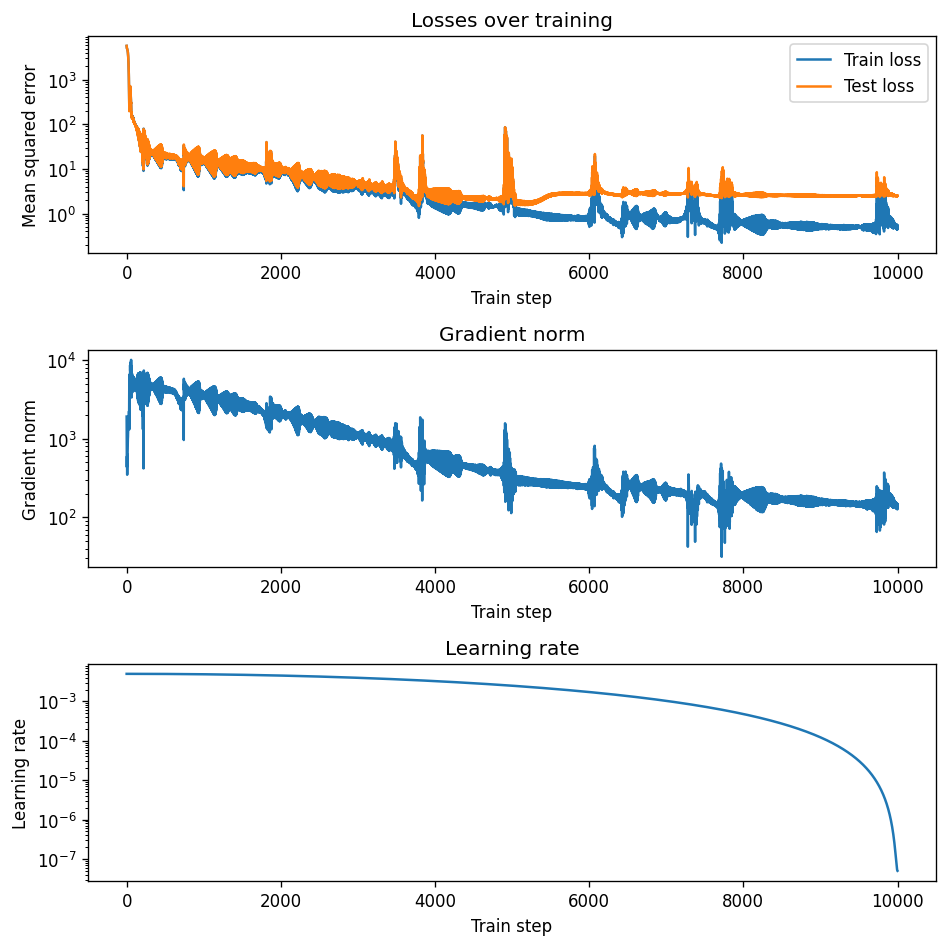

In [14]:
plt.figure(figsize=(8, 8), dpi=120)
plt.subplot(3, 1, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.yscale('log')
# plt.ylim(None, 2e6)
plt.title('Losses over training')
plt.xlabel("Train step") ; plt.ylabel("Mean squared error")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(gns)
plt.title('Gradient norm')
plt.xlabel("Train step") ; plt.ylabel("Gradient norm")
plt.yscale('log')
plt.subplot(3, 1, 3)
plt.plot(lrs)
plt.title('Learning rate')
plt.xlabel("Train step") ; plt.ylabel("Learning rate")
plt.yscale('log')
# plt.ylim(1e-5, None)
plt.tight_layout()

plt.show()

In [9]:
@jax.jit
def pred(params, batch):
    states, forces = batch
    _, q_t = jnp.split(states, 2, axis=-1)
    inp = normalize_dp(jnp.concatenate([states, forces], axis=-1))
    preds = jnp.concatenate([q_t,nn_forward_fn(params, inp)], axis=-1)
    return preds

Min test loss: 1.034754


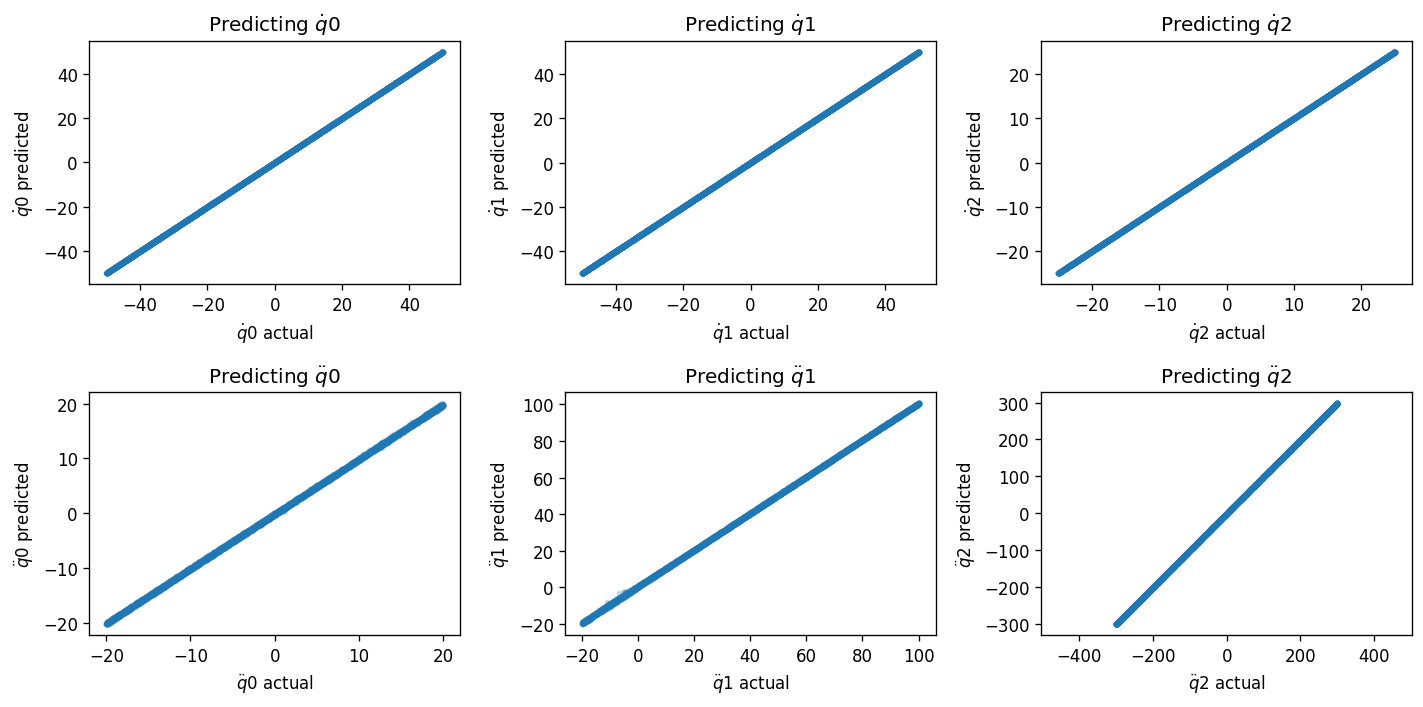

In [17]:
# xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test, f_test)
print(f"Min test loss: {min_loss:.6f}")
xt_pred = jax.vmap(partial(pred, min_loss_params))((x_test, f_test))

sampl = xt_pred.shape[0]

k = 0
fig, axes = plt.subplots(2, 3, figsize=(12,6), dpi=120)
for i in range(2):
    for j in range(3):
        axes[i][j].scatter(xt_test[:sampl, k], xt_pred[:sampl, k], s=6, alpha=0.2)
        deriv = r'\dot' if i == 0 else r'\ddot'
        axes[i][j].set_title(fr'Predicting ${deriv} q{j}$')
        axes[i][j].set_xlabel(fr'${deriv} q{j}$ actual')
        axes[i][j].set_ylabel(fr'${deriv} q{j}$ predicted')
        plt.axis('equal')
        k += 1
plt.tight_layout()
plt.show()

with open('min_loss_model_params.pkl', 'wb') as f:
    pickle.dump(min_loss_params, f)

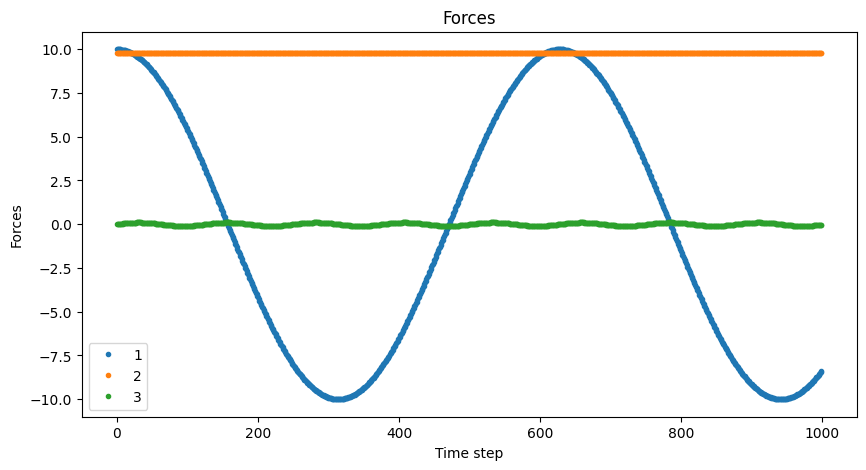

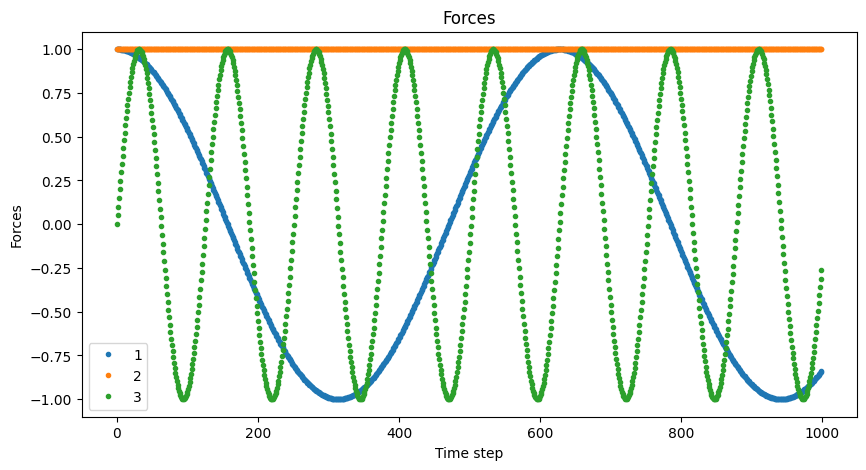

In [ ]:
# forcing_res =[]
# # forcing_fn = lambda t: np.array([np.cos(t), 2 * np.sin(t) + 8, np.sin(t)], dtype=np.float32)
# forcing_fn = lambda t: np.array([10 * np.cos(t) , 9.81, 0.1 * np.sin(5*t) ], dtype=np.float32)

# for i in jnp.linspace(0,10, num=1000):
#     forcing = forcing_fn(i)
#     # print(f"fx:{forcing[0]}, fz:{forcing[1]}, ftht:{forcing[2]}")
#     forcing_res.append(forcing)

# forcing_res = np.array(forcing_res)
# forcing_res

# plt.figure(figsize=(10,5))
# plt.plot(forcing_res, linestyle='None', marker='.')
# plt.legend([1,2,3])
# plt.title('Forces')
# plt.xlabel("Time step") ; plt.ylabel("Forces")
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(forcing_res/jnp.max(jnp.abs(forcing_res), axis=0), linestyle='None', marker='.')
# plt.legend([1,2,3])
# plt.title('Forces')
# plt.xlabel("Time step") ; plt.ylabel("Forces")
# plt.show()

In [14]:
# @jax.jit
# def dynamics(params, states, forces):
#     states = normalize_dp(states)
#     # def single_eom(x, f):
#     q, q_t = jnp.split(states, 2)
#     f = forces
#     L = learned_lagrangian(params)
#     # use jacfwd+grad instead of full hessian for a 3×3 mass matrix
#     M = jax.jacfwd(jax.grad(L, argnums=1), argnums=1)(q, q_t, f)
#     M_reg = M + 1e-4 * jnp.eye(M.shape[-1])   # add small diagonal
#     dLdq = jax.grad(L, argnums=0)(q, q_t, f)
#     C   = jax.jacfwd(jax.jacobian(L, argnums=1), argnums=0)(q, q_t, f)
#     q_tt = jnp.linalg.solve(M_reg, dLdq + f - C @ q_t)
#     return jnp.concatenate([q_t, q_tt])

@jax.jit
def dynamics(params, states, forces):
    _, q_t = jnp.split(states, 2, axis=-1)
    inp = normalize_dp(jnp.concatenate([states, forces], axis=-1))
    preds = jnp.concatenate([q_t, nn_forward_fn(params, inp)], axis=-1)
    return preds

In [ ]:
# x0 = jnp.concatenate([jnp.mean(pos, axis=0), jnp.mean(vel, axis=0)])
# tsteps = np.linspace(0, 10, num=1000)

# forcing_fn = lambda t: np.array([100 * np.cos(0.5*t) , 9, 5 * np.sin(0.5*t) ], dtype=np.float32)

# f = lambda state, t: dynamics(params, state, forcing_fn(t))

# xs = []
# ts = []

# for i, tim in enumerate(tsteps):
#     x0 = rk4_step(f, x0, i, tsteps[1]).copy()
#     # x0 = rk4_step_jit(f, x0, tim, 0.01)
#     # print(x0.device)
#     xs.append(x0)
#     ts.append(tim)
#     print(f"t={tim:.3f},{i}/{tsteps.shape[0]}", end='\n')
#     # print(x0)

t=0.000,0/1000
t=0.010,1/1000
t=0.020,2/1000
t=0.030,3/1000
t=0.040,4/1000
t=0.050,5/1000
t=0.060,6/1000
t=0.070,7/1000
t=0.080,8/1000
t=0.090,9/1000
t=0.100,10/1000
t=0.110,11/1000
t=0.120,12/1000
t=0.130,13/1000
t=0.140,14/1000
t=0.150,15/1000
t=0.160,16/1000
t=0.170,17/1000
t=0.180,18/1000
t=0.190,19/1000
t=0.200,20/1000
t=0.210,21/1000
t=0.220,22/1000
t=0.230,23/1000
t=0.240,24/1000
t=0.250,25/1000
t=0.260,26/1000
t=0.270,27/1000
t=0.280,28/1000
t=0.290,29/1000
t=0.300,30/1000
t=0.310,31/1000
t=0.320,32/1000
t=0.330,33/1000
t=0.340,34/1000
t=0.350,35/1000
t=0.360,36/1000
t=0.370,37/1000
t=0.380,38/1000
t=0.390,39/1000
t=0.400,40/1000
t=0.410,41/1000
t=0.420,42/1000
t=0.430,43/1000
t=0.440,44/1000
t=0.450,45/1000
t=0.460,46/1000
t=0.470,47/1000
t=0.480,48/1000
t=0.490,49/1000
t=0.501,50/1000
t=0.511,51/1000
t=0.521,52/1000
t=0.531,53/1000
t=0.541,54/1000
t=0.551,55/1000
t=0.561,56/1000
t=0.571,57/1000
t=0.581,58/1000
t=0.591,59/1000
t=0.601,60/1000
t=0.611,61/1000
t=0.621,62/1000
t=

In [15]:
x0 = jnp.array([0,0,0,0,0,0], dtype=np.float32)
tsteps = np.linspace(0, 50, num=5000)

forcing_fn = lambda t: np.array([1 * np.cos(0.5*t) , 9.81, 0 * np.sin(0.5*t) ], dtype=np.float32)

f = lambda state, t: dynamics(params, state, forcing_fn(t))

xs = []
xts = []
ts = []
frcs = []

for i, tim in enumerate(tsteps):
    xt = f(x0, tim)
    x0 = rk4_step(f, x0, tim, tsteps[1]).copy()
    frc = forcing_fn(tim)
    frcs.append(frc)
    xs.append(x0)
    xts.append(xt)
    ts.append(tim)
    print(f"t={tim:.3f},{i}/{tsteps.shape[0]}", end='\n')

t=0.000,0/5000
t=0.010,1/5000
t=0.020,2/5000
t=0.030,3/5000
t=0.040,4/5000
t=0.050,5/5000
t=0.060,6/5000
t=0.070,7/5000
t=0.080,8/5000
t=0.090,9/5000
t=0.100,10/5000
t=0.110,11/5000
t=0.120,12/5000
t=0.130,13/5000
t=0.140,14/5000
t=0.150,15/5000
t=0.160,16/5000
t=0.170,17/5000
t=0.180,18/5000
t=0.190,19/5000
t=0.200,20/5000
t=0.210,21/5000
t=0.220,22/5000
t=0.230,23/5000
t=0.240,24/5000
t=0.250,25/5000
t=0.260,26/5000
t=0.270,27/5000
t=0.280,28/5000
t=0.290,29/5000
t=0.300,30/5000
t=0.310,31/5000
t=0.320,32/5000
t=0.330,33/5000
t=0.340,34/5000
t=0.350,35/5000
t=0.360,36/5000
t=0.370,37/5000
t=0.380,38/5000
t=0.390,39/5000
t=0.400,40/5000
t=0.410,41/5000
t=0.420,42/5000
t=0.430,43/5000
t=0.440,44/5000
t=0.450,45/5000
t=0.460,46/5000
t=0.470,47/5000
t=0.480,48/5000
t=0.490,49/5000
t=0.500,50/5000
t=0.510,51/5000
t=0.520,52/5000
t=0.530,53/5000
t=0.540,54/5000
t=0.550,55/5000
t=0.560,56/5000
t=0.570,57/5000
t=0.580,58/5000
t=0.590,59/5000
t=0.600,60/5000
t=0.610,61/5000
t=0.620,62/5000
t=

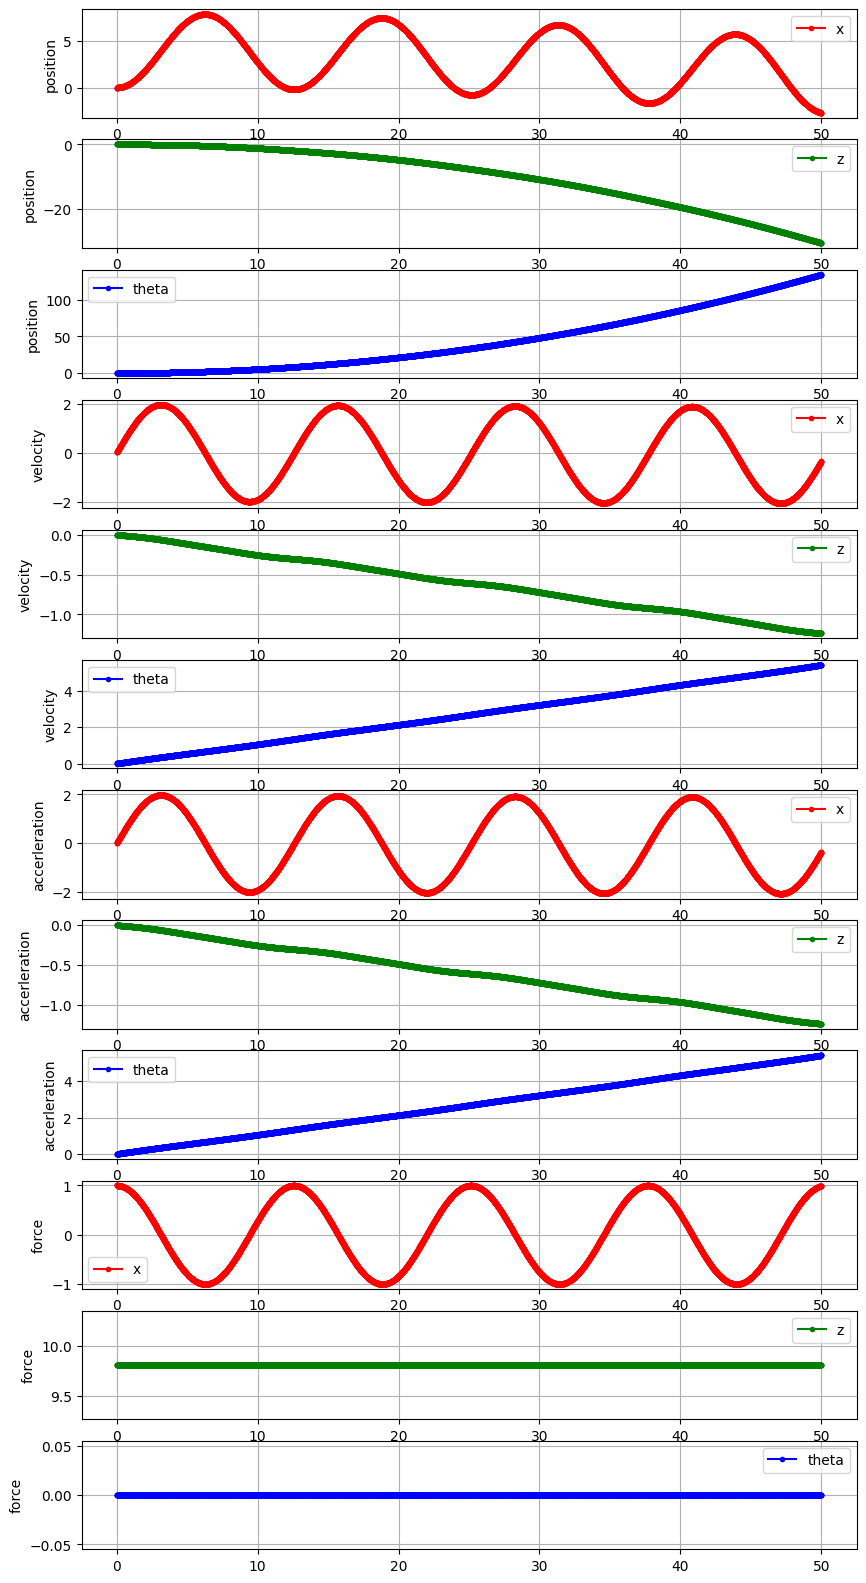

In [16]:
xs = np.array(xs[:])
xts = np.array(xts[:])
frcs = np.array(frcs[:])

cutoff = xs.shape[0] // 1

plt.figure(figsize=(10,20))

legends = ['x', 'z', 'theta']
labels = ['position', 'velocity', 'accerleration', 'force']
colors = ['red', 'green', 'blue']

for i in range(12):
    plt.subplot(12,1,i+1)
    if i < 6:
        plt.plot(ts[:cutoff], xs[:cutoff,i], linestyle='-', marker='.', color=colors[i%3])
    elif i < 9:
        plt.plot(ts[:cutoff], xts[:cutoff,i-6], linestyle='-', marker='.', color=colors[i%3])
    else:
        plt.plot(ts[:cutoff], frcs[:cutoff,i-9], linestyle='-', marker='.', color=colors[i%3])
    plt.legend([legends[i%3]])    
    plt.ylabel(labels[i//3])
    plt.grid()

In [18]:
with open('data/mlp_data.pkl','wb') as f:
    pickle.dump((ts, xs, xts, frcs), f)

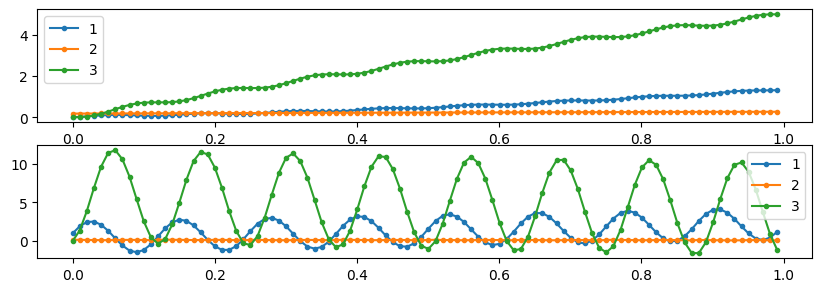

In [ ]:
# xs = np.array(xs[:])

# cutoff = xs.shape[0] // 10

# plt.figure(figsize=(10,5))
# plt.subplot(3,1,1)
# plt.plot(ts[:cutoff], xs[:cutoff,:3], linestyle='-', marker='.')
# plt.legend([1,2,3])

# plt.subplot(3,1,2)
# plt.plot(ts[:cutoff], xs[:cutoff,3:6], linestyle='-', marker='.')
# plt.legend([1,2,3])